In [1]:
import re
from urllib.request import urlopen

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [2]:
def load_armada(url: str) -> pd.DataFrame:
    text = urlopen(url).read().decode("utf-8")

    pattern = re.compile(
        r"([A-Za-z ]+?)\s+"   # 1: Battle name (letters + spaces)
        r"(\d{4})\s+"         # 2: Year (4 digits)
        r"(\d+)\s+"           # 3: Portuguese ships
        r"(\d+)\s+"           # 4: Dutch ships
        r"(\d+)\s+"           # 5: English ships
        r"([\d.]+)\s+"        # 6: Ratio
        r"(\d+)\s+"           # 7: Spanish involvement (0/1)
        r"(-?\d+)"            # 8: Outcome (-1, 0, 1)
    )

    rows = []
    for m in pattern.finditer(text):
        battle = m.group(1).strip()
        year = int(m.group(2))
        port = int(m.group(3))
        dutch = int(m.group(4))
        eng = int(m.group(5))
        ratio = float(m.group(6))
        spanish = int(m.group(7))
        outcome = int(m.group(8))
        rows.append([battle, year, port, dutch, eng, ratio, spanish, outcome])

    columns = [
        "Battle",
        "Year",
        "Portuguese_ships",
        "Dutch_ships",
        "English_ships",
        "Ratio",
        "Spanish_involvement",
        "Outcome"  # -1 = defeat, 0 = draw, 1 = victory
    ]
    return pd.DataFrame(rows, columns=columns)


url = "https://users.stat.ufl.edu/~winner/data/armada.dat"
df = load_armada(url)

print("First few rows:")
print(df.head(), "\n")
print("Outcome counts:")
print(df["Outcome"].value_counts(), "\n")

First few rows:
           Battle  Year  Portuguese_ships  Dutch_ships  English_ships  Ratio  \
0          Bantam  1601                 6            3              0  2.000   
1  Malacca Strait  1606                14           11              0  1.273   
2   Ilha das Naus  1606                 6            9              0  0.667   
3      Pulo Butum  1606                 7            9              0  0.778   
4          Surrat  1615                 6            0              4  1.500   

   Spanish_involvement  Outcome  
0                    0        0  
1                    0        0  
2                    0       -1  
3                    0        1  
4                    0        0   

Outcome counts:
Outcome
 0    13
-1    10
 1     5
Name: count, dtype: int64 



In [3]:
df

,Battle,Year,Portuguese_ships,Dutch_ships,English_ships,Ratio,Spanish_involvement,Outcome
0,Bantam,1601,6,3,0,2.000,0,0
1,Malacca Strait,1606,14,11,0,1.273,0,0
2,Ilha das Naus,1606,6,9,0,0.667,0,-1
3,Pulo Butum,1606,7,9,0,0.778,0,1
4,Surrat,1615,6,0,4,1.500,0,0
5,Ilha das Naus,1615,3,5,0,0.600,0,-1
6,Jask,1620,4,0,4,1.000,0,0
7,Hormuz,1622,6,0,5,1.200,0,-1
8,Mogincoal Shoals,1622,4,4,2,0.667,0,-1
9,Hormuz,1625,8,4,4,1.000,0,0


In [4]:
# Prepare features and target
X = df[[
    "Portuguese_ships",
    "Dutch_ships",
    "English_ships",
    "Ratio",
    "Spanish_involvement"
]]
y = df["Outcome"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

In [5]:
# SVM classifier (main model)
svm_clf = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="rbf"))
])

svm_clf.fit(X_train, y_train)
svm_pred = svm_clf.predict(X_test)

print("=== SVM RESULTS ===")
print("Accuracy:", accuracy_score(y_test, svm_pred))
print("Confusion matrix:\n", confusion_matrix(y_test, svm_pred))
print("Classification report:\n", classification_report(y_test, svm_pred))

=== SVM RESULTS ===
Accuracy: 0.42857142857142855
Confusion matrix:
 [[0 3 0]
 [0 3 0]
 [0 1 0]]
Classification report:
               precision    recall  f1-score   support

          -1       0.00      0.00      0.00         3
           0       0.43      1.00      0.60         3
           1       0.00      0.00      0.00         1

    accuracy                           0.43         7
   macro avg       0.14      0.33      0.20         7
weighted avg       0.18      0.43      0.26         7



/Users/stevegon/SynologyDrive/code/uw/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/stevegon/SynologyDrive/code/uw/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/stevegon/SynologyDrive/code/uw/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

In [6]:
#Logistic Regression
log_clf = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(max_iter=1000, multi_class="multinomial"))
])

log_clf.fit(X_train, y_train)
log_pred = log_clf.predict(X_test)

print("\n=== LOGISTIC REGRESSION RESULTS ===")
print("Accuracy:", accuracy_score(y_test, log_pred))
print("Confusion matrix:\n", confusion_matrix(y_test, log_pred))
print("Classification report:\n", classification_report(y_test, log_pred))




=== LOGISTIC REGRESSION RESULTS ===
Accuracy: 0.5714285714285714
Confusion matrix:
 [[3 0 0]
 [2 1 0]
 [0 1 0]]
Classification report:
               precision    recall  f1-score   support

          -1       0.60      1.00      0.75         3
           0       0.50      0.33      0.40         3
           1       0.00      0.00      0.00         1

    accuracy                           0.57         7
   macro avg       0.37      0.44      0.38         7
weighted avg       0.47      0.57      0.49         7



/Users/stevegon/SynologyDrive/code/uw/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/Users/stevegon/SynologyDrive/code/uw/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/stevegon/SynologyDrive/code/uw/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize

In [7]:
# Random Forest 
rf_clf = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)

rf_clf.fit(X_train, y_train)
rf_pred = rf_clf.predict(X_test)

print("\n=== RANDOM FOREST RESULTS ===")
print("Accuracy:", accuracy_score(y_test, rf_pred))
print("Confusion matrix:\n", confusion_matrix(y_test, rf_pred))
print("Classification report:\n", classification_report(y_test, rf_pred))


=== RANDOM FOREST RESULTS ===
Accuracy: 0.2857142857142857
Confusion matrix:
 [[1 2 0]
 [1 1 1]
 [0 1 0]]
Classification report:
               precision    recall  f1-score   support

          -1       0.50      0.33      0.40         3
           0       0.25      0.33      0.29         3
           1       0.00      0.00      0.00         1

    accuracy                           0.29         7
   macro avg       0.25      0.22      0.23         7
weighted avg       0.32      0.29      0.29         7



### Analysis:

In [8]:
svm_pred = svm_clf.predict(X_test)
log_pred = log_clf.predict(X_test)
rf_pred  = rf_clf.predict(X_test)

In [9]:
from sklearn.metrics import accuracy_score, f1_score

# Accuracy for each model
acc_svm = accuracy_score(y_test, svm_pred)
acc_log = accuracy_score(y_test, log_pred)
acc_rf  = accuracy_score(y_test, rf_pred)

# Optional: macro F1 for each model (treats classes equally)
f1_svm = f1_score(y_test, svm_pred, average="macro")
f1_log = f1_score(y_test, log_pred, average="macro")
f1_rf  = f1_score(y_test, rf_pred,  average="macro")

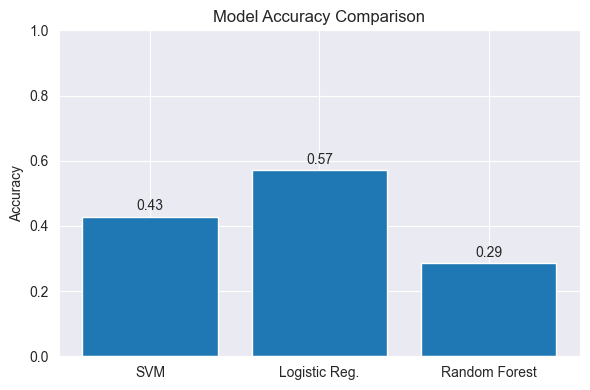

In [10]:
import matplotlib.pyplot as plt

models = ["SVM", "Logistic Reg.", "Random Forest"]
accuracies = [acc_svm, acc_log, acc_rf]

plt.figure(figsize=(6,4))
plt.bar(models, accuracies)
plt.ylim(0, 1)
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")

# Add value labels on top of bars
for i, v in enumerate(accuracies):
    plt.text(i, v + 0.02, f"{v:.2f}", ha="center")

plt.tight_layout()
plt.show()

The Support Vector Machine (SVM) model predicted all draw outcomes (class 0) but not defeats (–1) or victories (1) with an accuracy of 0.43. The confusion matrix shows that the model predicted every test observation's draw class. Class 0 recall was 1.00, while classes –1 and 1 were 0. SVM collapsed into a single majority-like class, consistent with small sample sizes and limited class separation.

Logistic Regression was more accurate, scoring 0.57. It correctly identified all three defeats (class –1), achieving 1.00 class recall. However, it only identified one of three draws correctly and missed the test set victory. Logistic Regression outperformed the SVM by predicting across classes, but its linear decision boundary limited its ability to distinguish draws and victories.

The Random Forest model had the lowest accuracy at 0.29 and mixed performance across all three classes. It correctly predicted one loss and one draw but misclassified many others, including the only win. The confusion matrix suggests that the model tried to use its nonlinear splitting structure but was unstable due to the small dataset and imbalanced class distribution. All classes had inconsistent predictions and low precision and recall.

Logistic Regression performed best on this dataset, followed by SVM and Random Forest. The SVM's tendency to predict only draws limited its usefulness despite its theoretically powerful nonlinear modeling capabilities. Overfitting and the small training size hurt the Random Forest most. Logistic Regression yielded the most accurate results, but the Portuguese sea battles dataset's few observations and uneven class distribution limited all three models.